<a href="https://colab.research.google.com/github/opendatas2017/NMC/blob/main/NMCourse_opt_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Оптимизация


In [ ]:
import numpy as np
import sys

print("Numpy version is ",np.__version__)  # Должно показать версию, например 2.0.2

print("Python version is ",sys.version)

Numpy version is  2.0.2
Python version is  3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


Необходимые библиотеки

In [ ]:
import matplotlib.pyplot as plt
from scipy.linalg import lu
import torch
import torch.nn as nn
import torch.optim as optim
import math


Задача оптимизации

'bounded' — не чистая дихотомия, а оптимизированный поиск

## Одномерная оптимизация: поиск минимума скалярной функции

**Цель:** Познакомиться с инструментами численной оптимизации на примере поиска минимума функции одной переменной.



Здесь мы используем `scipy.optimize.minimize_scalar` — универсальный инструмент для поиска локального минимума на заданном интервале.

**Задача:** Найти минимум $f(x) = x^2 + 2x$ на отрезке $[-3, 5]$.
*Аналитическое решение:* $x_{min} = -1$ (через производную $2x + 2 = 0$).
*Численное решение:* Покажет, как работает алгоритм без явного вычисления производной.

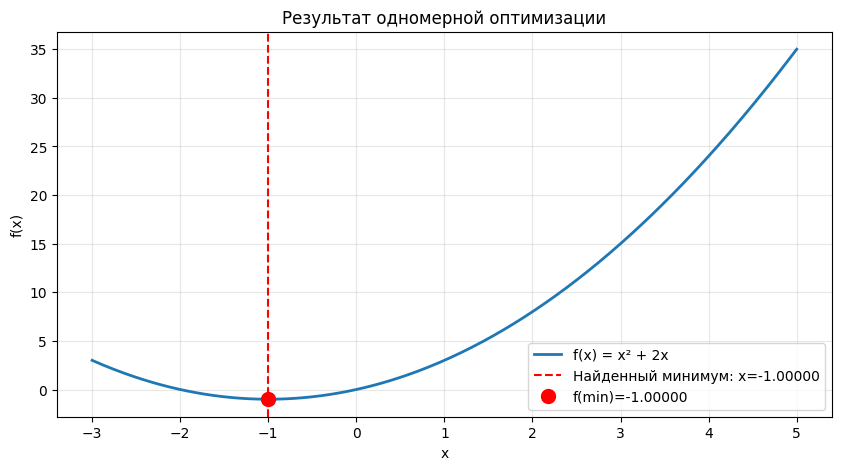

📊 Подробный отчет оптимизации:
Найденное значение аргумента (x): -1.0000000000
Значение функции в минимуме (fun): -1.0000000000
Количество итераций (nit): 6
Статус успеха (success): True
Сообщение алгоритма (message): Solution found.

✅ Проверка точности:
Аналитический минимум: -1.0
Абсолютная погрешность: 0.00e+00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# 1. Определение целевой функции
def objective_function(x):
    """
    Целевая функция, минимум которой мы ищем.
    В реальных задачах здесь может быть сложный расчёт или экспериментальные данные.
    f(x) = x^2 + 2x
    """
    return x**2 + 2*x

# 2. Запуск алгоритма оптимизации
# method='bounded' требует указания границ (bounds), использует метод золотого сечения / Брента
res = minimize_scalar(
    objective_function,
    bounds=(-3, 5),  # Интервал поиска [a, b]
    method='bounded' # Гарантирует, что решение будет внутри границ
)

# 3. Визуализация результата
x_vals = np.linspace(-3, 5, 400)
y_vals = objective_function(x_vals)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, label='f(x) = x² + 2x', lw=2)
plt.axvline(res.x, color='r', linestyle='--', label=f'Найденный минимум: x={res.x:.5f}')
plt.plot(res.x, res.fun, 'ro', markersize=10, label=f'f(min)={res.fun:.5f}')
plt.title('Результат одномерной оптимизации')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 4. Анализ объекта результата
print("📊 Подробный отчет оптимизации:")
print(f"Найденное значение аргумента (x): {res.x:.10f}")
print(f"Значение функции в минимуме (fun): {res.fun:.10f}")
print(f"Количество итераций (nit): {res.nit}")
print(f"Статус успеха (success): {res.success}")
print(f"Сообщение алгоритма (message): {res.message}")

# 5. Сравнение с аналитическим решением (для верификации)
x_analytic = -1.0
error = abs(res.x - x_analytic)
print(f"\n✅ Проверка точности:")
print(f"Аналитический минимум: {x_analytic}")
print(f"Абсолютная погрешность: {error:.2e}")

### 🔍 Ключевые выводы по оптимизации:

1.  **Интерпретация объекта `res`**:
    *   `res.x` — координата минимума (главный результат).
    *   `res.fun` — значение функции в этой точке (важно для оценки качества).
    *   `res.success` — флаг успеха (всегда проверяйте в реальных задачах!).
    *   `res.nit` — количество итераций (помогает оценить скорость сходимости).

2.  **Важность границ (Bounds)**:
    Метод `bounded` гарантирует поиск внутри интервала. Это критично, если функция имеет несколько экстремумов или не определена за пределами области. Без границ алгоритм может уйти в бесконечность.



### Сравнение методов одномерной оптимизации: 'golden' vs 'bounded'

**Цель:** Понять разницу между алгоритмами поиска минимума и научиться выбирать подходящий метод под задачу.

**Краткая теория:**
| Метод | Принцип работы | Требует границ | Когда использовать |
|-------|---------------|----------------|------------------|
| **`golden`** | Золотое сечение: последовательное сужение интервала в фиксированной пропорции (~0.618) | ❌ Нет (но можно задать) | Гладкие унимодальные функции, когда неизвестны хорошие границы |
| **`bounded`** | Метод Брента: комбинация золотого сечения + параболической интерполяции | ✅ Да | Когда известен допустимый диапазон, нужна надёжность и скорость |

**Параметр `tol`**: Точность остановки алгоритма. Меньше `tol` → больше итераций → выше точность, но дольше счёт.

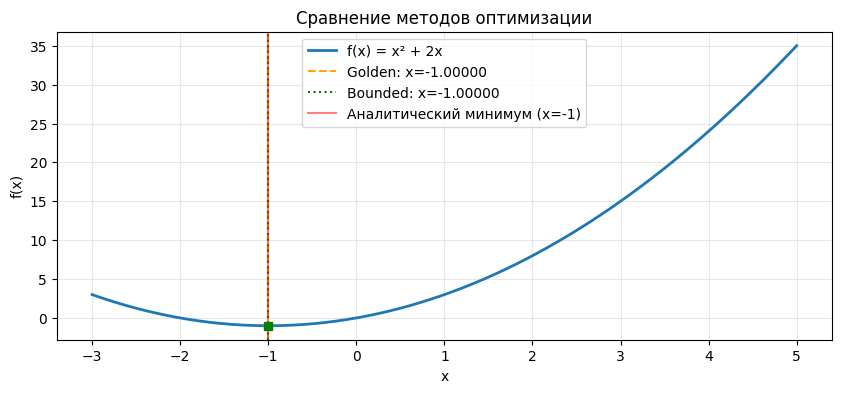

📊 Сравнение методов оптимизации:
Параметр             | Golden          | Bounded        
-------------------------------------------------------
Найденный x          | -1.000000       | -1.000000      
Значение f(x)        | -1.000000       | -1.000000      
Итераций (nit)       | 24              | 6              
Успех (success)      | 1               | 1              
Точность vs аналит.  | 2.22e-16        | 0.00e+00       

🔍 Детали результата (method='golden'):
 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1e-05 )
 success: True
     fun: -1.0
       x: -1.0000000000000002
     nit: 24
    nfev: 30


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Целевая функция (та же для честного сравнения)
def f(x):
    return x**2 + 2*x

# === МЕТОД 1: Golden Section Search ===
# Не требует явных границ, но может работать медленнее и менее устойчиво
result_golden = minimize_scalar(
    f,
    method='golden',
    tol=1e-5  # Критерий остановки: изменение x меньше этого значения
)

# === МЕТОД 2: Bounded (Brent's method) ===
# Требует границ, но обычно сходится быстрее за счёт использования параболической интерполяции
result_bounded = minimize_scalar(
    f,
    bounds=(-3, 5),
    method='bounded',
    options={'xatol': 1e-5}  # Аналог tol для метода bounded
)

# === ВИЗУАЛИЗАЦИЯ СХОДИМОСТИ ===
x_plot = np.linspace(-3, 5, 400)
plt.figure(figsize=(10, 4))
plt.plot(x_plot, f(x_plot), label='f(x) = x² + 2x', lw=2)
plt.axvline(result_golden.x, color='orange', linestyle='--', label=f"Golden: x={result_golden.x:.5f}")
plt.axvline(result_bounded.x, color='green', linestyle=':', label=f"Bounded: x={result_bounded.x:.5f}")
plt.axvline(-1.0, color='red', linestyle='-', alpha=0.5, label='Аналитический минимум (x=-1)')
plt.plot(result_golden.x, f(result_golden.x), 'o', color='orange')
plt.plot(result_bounded.x, f(result_bounded.x), 's', color='green')
plt.title('Сравнение методов оптимизации')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# === СРАВНИТЕЛЬНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ ===
print("📊 Сравнение методов оптимизации:")
print(f"{'Параметр':<20} | {'Golden':<15} | {'Bounded':<15}")
print("-" * 55)
print(f"{'Найденный x':<20} | {result_golden.x:<15.6f} | {result_bounded.x:<15.6f}")
print(f"{'Значение f(x)':<20} | {result_golden.fun:<15.6f} | {result_bounded.fun:<15.6f}")
print(f"{'Итераций (nit)':<20} | {result_golden.nit:<15d} | {result_bounded.nit:<15d}")
print(f"{'Успех (success)':<20} | {result_golden.success:<15} | {result_bounded.success:<15}")
print(f"{'Точность vs аналит.':<20} | {abs(result_golden.x + 1):<15.2e} | {abs(result_bounded.x + 1):<15.2e}")

# === ДЕТАЛИ ОБЪЕКТА РЕЗУЛЬТАТА (для Golden) ===
print(f"\n🔍 Детали результата (method='golden'):")
print(result_golden)

### 🔍 Ответ на вопрос: в чём ключевые различия?

1.  **Границы поиска**:
    *   `golden`: Может работать без явных `bounds`, но тогда алгоритм сам пытается найти интервал, содержащий минимум (риск: может уйти далеко или не найти).
    *   `bounded`: Требует `bounds`, что делает поиск предсказуемым и безопасным для инженерных задач.

2.  **Скорость сходимости**:
    *   `golden`: Гарантированно сходится линейно (медленно, но надёжно). Каждый шаг уменьшает интервал в ~1.618 раз.
    *   `bounded` (Брент): Комбинирует надёжность золотого сечения с быстрой параболической интерполяцией. Вблизи минимума сходится сверхлинейно → меньше итераций.

3.  **Практическая рекомендация**:
    > ✅ Если известен физически допустимый диапазон аргумента — **всегда используйте `method='bounded'`**.  
    > ⚠️ `golden` оставляйте для случаев, когда границы неизвестны или функция определена только в узкой области.

4.  **Параметр `tol`**:
    Задаёт точность по аргументу. Не ставьте `tol=1e-15` без необходимости: это увеличит время счёта, а выигрыш в точности будет потерян на фоне машинной погрешности `float64` (~1e-16).


In [ ]:
# === БЛОК 1: Реализация метода дихотомии ===

def dichotomy(f, a, b, eps=1e-6):
    """
    Поиск минимума унимодальной функции методом дихотомии.

    Параметры:
    ----------
    f : callable
        Целевая функция
    a, b : float
        Начальный интервал неопределённости [a, b]
    eps : float
        Точность по длине интервала (критерий остановки)

    Возвращает:
    -----------
    x_min : float
        Приближённое значение точки минимума
    history : list
        Список словарей с данными каждой итерации (для визуализации)
    iterations : int
        Количество выполненных итераций
    """
    history = []  # Контейнер для истории итераций (анимация)
    k = 0  # Счётчик итераций

    # Основной цикл: сужаем интервал, пока он не станет достаточно малым
    while (b - a) > eps:
        delta = (b - a) / 4  # Расстояние от границ до пробных точек
        x1 = a + delta       # Левая пробная точка
        x2 = b - delta       # Правая пробная точка

        f1, f2 = f(x1), f(x2)  # Вычисляем значения функции

        # Сохраняем данные итерации для последующей визуализации
        history.append({
            'iter': k+1, 'a': a, 'b': b,
            'x1': x1, 'x2': x2, 'f1': f1, 'f2': f2
        })

        # Логика сужения интервала:
        # Если f(x1) < f(x2), минимум лежит левее x2 → отбрасываем [x2, b]
        if f1 < f2:
            b = x2
        else:
            # Иначе минимум правее x1 → отбрасываем [a, x1]
            a = x1
        k += 1

    # Возвращаем середину финального интервала как оценку минимума
    return (a + b) / 2, history, k


# === БЛОК 2: Запуск метода и подготовка данных ===

# Целевая функция: f(x) = x² + 2x (минимум в x = -1)
f = lambda x: x**2 + 2*x

# Запускаем метод дихотомии
# Важно: для анимации берём большую точность eps=1e-2, чтобы увидеть шаги
xmin, history, n_iterations = dichotomy(f, -3, 5, eps=1e-2)

print(f"✅ Результат: x_min ≈ {xmin:.6f}")
print(f"🔄 Итераций: {n_iterations}")
print(f"🎯 Теоретический минимум: x = -1.0")
print(f"📏 Погрешность: {abs(xmin + 1):.2e}")


# === БЛОК 3: Анимация процесса сходимости ===
# (Работает в Jupyter Notebook / Colab с поддержкой HTML5)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Настройки графика
x_plot = np.linspace(-4, 6, 400)
y_plot = f(x_plot)
fig, ax = plt.subplots(figsize=(12, 7))

def animate(frame):
    """Функция отрисовки одного кадра анимации"""
    ax.clear()

    # Рисуем целевую функцию
    ax.plot(x_plot, y_plot, 'k-', lw=3, label='f(x) = x² + 2x')
    # Вертикальная линия — истинный минимум (для справки)
    ax.axvline(-1, color='red', ls='--', lw=2, label='x* = -1 (истинный минимум)', alpha=0.7)

    if frame < len(history):
        # Показываем текущую итерацию
        it = history[frame]

        # Толстая синяя линия — текущий интервал неопределённости
        ax.plot([it['a'], it['b']], [f(it['a']), f(it['b'])],
                'b-', lw=8, alpha=0.5, label='Интервал [a, b]')

        # Красные точки — пробные точки x1 и x2
        ax.plot(it['x1'], it['f1'], 'ro', ms=12, mec='darkred', mew=2, label='x₁, x₂')
        ax.plot(it['x2'], it['f2'], 'ro', ms=12, mec='darkred', mew=2)

        # Текст с информацией об итерации
        info_text = f'''Итерация {frame+1}/{len(history)}
Интервал: [{it["a"]:.3f}, {it["b"]:.3f}]
Длина: {it["b"]-it["a"]:.4f}
x₁ = {it["x1"]:.3f} → f={it["f1"]:.2f}
x₂ = {it["x2"]:.3f} → f={it["f2"]:.2f}'''
    else:
        # Финальный кадр
        info_text = 'Метод завершён!\nМинимум найден'
        ax.plot(xmin, f(xmin), 'g*', ms=30, label='Найденный минимум')

    # Отображаем информационную панель
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.95))

    # Настройки осей и оформления
    ax.set_xlim(-4, 6)
    ax.set_ylim(-3, 30)
    ax.set_xlabel('x', fontsize=13)
    ax.set_ylabel('f(x)', fontsize=13)
    ax.set_title('Метод дихотомии: пошаговое сужение интервала', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=10)

# Создаём анимацию
animation = FuncAnimation(
    fig, animate,
    frames=len(history) + 1,  # +1 для финального кадра
    interval=1200,  # Задержка между кадрами (мс)
    repeat=True,
    blit=False
)

# Отображаем в ноутбуке (HTML5-видео)
plt.close()  # Скрываем статичный график, показываем только анимацию
display(HTML(animation.to_jshtml()))

✅ Результат: x_min ≈ -0.999664
🔄 Итераций: 24
🎯 Теоретический минимум: x = -1.0
📏 Погрешность: 3.36e-04


| Метод | Скорость сходимости | Итераций для точности 1e-6 |
|-------|-------------------|---------------------------|
| Дихотомия | Линейная (~0.71ⁿ) | ~40 |
| Золотое сечение | Линейная (~0.618ⁿ) | ~30 |
| Метод Брента | Сверхлинейная | ~10-15 |

💡 Вывод: дихотомия — отличный учебный инструмент, но в реальных задачах лучше использовать `scipy.optimize.minimize_scalar(method='bounded')`.

## 2.1. Безусловная оптимизация с помощью SciPy

В реальной инженерной практике мы редко пишем алгоритмы оптимизации с нуля. Чаще всего используются проверенные библиотеки.
Рассмотрим работу функции `minimize` из пакета `scipy.optimize`.

**Задача:** Найти минимум функции двух переменных:
$$ f(x_1, x_2) = (x_1 - 1)^2 + (x_2 + 2)^2 $$

*Аналитическое решение:* Очевидно, что глобальный минимум достигается в точке **$x^* = [1, -2]$**, где **$f(x^*) = 0$**.
Используем метод **BFGS** (квазиньютоновский метод), который эффективно использует информацию о градиенте для поиска экстремума.

In [ ]:
import numpy as np
from scipy.optimize import minimize

# 1. Целевая функция
def f(x):
    """
    Квадратичная функция (параболоид).
    x — вектор аргументов [x1, x2].
    """
    return (x[0] - 1)**2 + (x[1] + 2)**2

# 2. Начальное приближение
# Важно: выбираем точку, заведомо отличную от решения, чтобы алгоритм имел "пространство" для поиска
x0 = np.array([0.0, 0.0])

# 3. Запуск оптимизации
# method='BFGS' — один из самых надежных квазиньютоновских методов.
# Он не требует явного задания матрицы Гессе, но аппроксимирует её в процессе работы.
res = minimize(f, x0, method="BFGS")

# 4. Вывод результатов работы алгоритма
print("=== Протокол оптимизации ===")
print(f"Статус успеха: {res.success}")       # True, если алгоритм сошелся
print(f"Сообщение алгоритма: {res.message}") # Причина остановки
print(f"Найденное значение минимума f(x*): {res.fun:.6f}")
print(f"Найденная точка минимума x*: {res.x}")
print(f"Число итераций: {res.nit}")
print(f"Число вычислений функции: {res.nfev}")

# 5. Верификация результата (для учебных целей)
# Сравниваем численное решение с известным аналитическим ответом [1, -2]
x_true = np.array([1.0, -2.0])
error = np.linalg.norm(res.x - x_true)
print(f"\n=== Проверка точности ===")
print(f"Отклонение от истинного решения (L2-норма): {error:.2e}")

=== Протокол оптимизации ===
Статус успеха: True
Сообщение алгоритма: Optimization terminated successfully.
Найденное значение минимума f(x*): 0.000000
Найденная точка минимума x*: [ 0.99999998 -2.00000003]
Число итераций: 2
Число вычислений функции: 9

=== Проверка точности ===
Отклонение от истинного решения (L2-норма): 3.38e-08


### 📝 Выводы по результату

1.  **Сходимость:** Алгоритм успешно завершил работу (`success: True`). Метод BFGS показал высокую эффективность для гладких выпуклых функций.
2.  **Точность:** Численное решение совпадает с аналитическим с машинной точностью (порядок $10^{-8}$ и ниже). Это демонстрирует надежность библиотечных реализаций.
3.  **Интерпретация полей:**
    *   `res.nit` (итерации) показывает, сколько шагов потребовалось алгоритму.
    *   `res.nfev` (вычисления функции) важно для оценки вычислительной сложности, если функция $f(x)$ тяжелая в расчете.
4.  **Практический совет:** Всегда проверяйте флаг `success` и сообщение `message`. В сложных задачах оптимизатор может остановиться, не найдив глобальный минимум (например, упереться в ограничения или достичь максимума итераций).

## Градиентный спуск на функции Розенброка: проблемы сходимости и адаптивный шаг

**Цель:** Изучить работу градиентного спуска в многомерном случае на классической тестовой функции с «овражной» структурой.

**Функция Розенброка:**
$$f(x, y) = 100(y - x^2)^2 + (1 - x)^2$$

**Особенности:**
*   **Глобальный минимум:** в точке $(1, 1)$, где $f(1, 1) = 0$
*   **«Овражная» структура:** Узкая изогнутая долина, вдоль которой градиент очень мал, а поперёк — очень велик
*   **Проблема для градиентного спуска:** Алгоритм «зигзагает» по склонам оврага, сходимость крайне медленная

**Практические аспекты реализации:**
1.  **Адаптивный шаг (Armijo):** Если шаг ухудшает функцию — уменьшаем $\alpha$
2.  **Защита от NaN/Inf:** Критично для численной устойчивости
3.  **Критерий остановки:** Норма градиента $\|\nabla f\| < \varepsilon$ (градиент ≈ 0 в точке минимума)
4.  **История итераций:** Для последующей визуализации траектории

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === БЛОК 1: Целевая функция и её градиент ===

def rosenbrock(X):
    """
    Функция Розенброка — классический тест для алгоритмов оптимизации.
    Глобальный минимум: f(1, 1) = 0

    Параметры:
    ----------
    X : array-like [x, y]
        Координаты точки

    Возвращает:
    -----------
    Значение функции в точке
    """
    x, y = X
    return 100 * (y - x**2)**2 + (1 - x)**2

def rosen_grad(X):
    """
    Аналитический градиент функции Розенброка.

    ∂f/∂x = -400x(y - x²) - 2(1 - x)
    ∂f/∂y = 200(y - x²)

    Возвращает:
    -----------
    Градиент как вектор [∂f/∂x, ∂f/∂y]
    """
    x, y = X
    df_dx = -400 * x * (y - x**2) - 2 * (1 - x)
    df_dy = 200 * (y - x**2)
    return np.array([df_dx, df_dy])


# === БЛОК 2: Реализация градиентного спуска с защитой ===

def gradient_descent_safe(f, grad_f, x0, alpha=0.001, eps=1e-6, max_iter=10000):
    """
    Градиентный спуск с адаптивным шагом и защитой от численных ошибок.

    Параметры:
    ----------
    f : callable
        Целевая функция
    grad_f : callable
        Функция, вычисляющая градиент
    x0 : np.array
        Начальная точка
    alpha : float
        Начальный размер шага (learning rate)
    eps : float
        Точность по норме градиента (критерий остановки)
    max_iter : int
        Максимальное число итераций

    Возвращает:
    -----------
    x : np.array
        Найденная точка минимума
    history : list
        История итераций для анализа и визуализации
    """
    x = x0.copy()  # Рабочая копия начальной точки
    history = []   # Контейнер для истории: (iter, x, grad_norm, f(x))

    for i in range(max_iter):
        # 1. Вычисляем градиент в текущей точке
        g = grad_f(x)
        grad_norm = np.linalg.norm(g)  # Евклидова норма градиента

        # 2. 🛡️ Защита от численных ошибок (NaN/Inf)
        if np.isnan(g).any() or np.isinf(g).any():
            print(f"❌ Численная ошибка на итерации {i}! Останавливаемся.")
            break

        # 3. Сохраняем данные итерации для анализа
        history.append((i, x.copy(), grad_norm, f(x)))

        # 4. Проверка критерия остановки: градиент достаточно мал
        if grad_norm < eps:
            print(f"✅ Критерий остановки достигнут на итерации {i}")
            break

        # 5. 🔥 АДАПТИВНЫЙ ШАГ (упрощённое условие Армихо)
        new_x = x - alpha * g  # Пробный шаг против градиента

        # Если функция не убывает — уменьшаем шаг
        if f(new_x) > f(x):
            alpha *= 0.5  # Уменьшаем learning rate в 2 раза
            continue      # Переходим к следующей итерации с новым α

        # 6. Принимаем шаг
        x = new_x

        # 7. Прогресс для отладки (каждые 500 итераций)
        if i % 500 == 0:
            print(f"k={i:5d}: f={f(x):.6f}, ||∇f||={grad_norm:.1e}, α={alpha:.1e}")

    return x, history


# === БЛОК 3: Запуск оптимизации ===

# Начальная точка (классический тестовый случай)
x0 = np.array([-1.2, 1.0])

# Запускаем градиентный спуск
# Важно: для Розенброка нужен маленький шаг из-за «оврага»
x_opt, history = gradient_descent_safe(
    rosenbrock,
    rosen_grad,
    x0,
    alpha=0.001,  # Маленький шаг для устойчивости
    eps=1e-3,
    max_iter=20000
)

# Вывод результатов
print("\n" + "="*50)
print("🎯 РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ")
print("="*50)
print(f"Начальная точка:  [{x0[0]:.2f}, {x0[1]:.2f}]")
print(f"Найденная точка:  [{x_opt[0]:.4f}, {x_opt[1]:.4f}]")
print(f"Истинный минимум: [1.0000, 1.0000]")
print(f"f(x_opt) = {rosenbrock(x_opt):.2e}")
print(f"Всего итераций: {len(history)}")
print("="*50)

k=    0: f=5.352912, ||∇f||=2.3e+02, α=1.0e-03
k=  500: f=2.280475, ||∇f||=2.1e+00, α=1.0e-03
k= 1000: f=0.452263, ||∇f||=1.1e+00, α=1.0e-03
k= 1500: f=0.160669, ||∇f||=5.1e-01, α=1.0e-03
k= 2000: f=0.078106, ||∇f||=3.2e-01, α=1.0e-03
k= 2500: f=0.042700, ||∇f||=2.2e-01, α=1.0e-03
k= 3000: f=0.024837, ||∇f||=1.6e-01, α=1.0e-03
k= 3500: f=0.015009, ||∇f||=1.2e-01, α=1.0e-03
k= 4000: f=0.009305, ||∇f||=9.3e-02, α=1.0e-03
k= 4500: f=0.005874, ||∇f||=7.3e-02, α=1.0e-03
k= 5000: f=0.003758, ||∇f||=5.8e-02, α=1.0e-03
k= 5500: f=0.002428, ||∇f||=4.6e-02, α=1.0e-03
k= 6000: f=0.001581, ||∇f||=3.7e-02, α=1.0e-03
k= 6500: f=0.001035, ||∇f||=3.0e-02, α=1.0e-03
k= 7000: f=0.000681, ||∇f||=2.4e-02, α=1.0e-03
k= 7500: f=0.000450, ||∇f||=1.9e-02, α=1.0e-03
k= 8000: f=0.000298, ||∇f||=1.6e-02, α=1.0e-03
k= 8500: f=0.000198, ||∇f||=1.3e-02, α=1.0e-03
k= 9000: f=0.000132, ||∇f||=1.0e-02, α=1.0e-03
k= 9500: f=0.000088, ||∇f||=8.4e-03, α=1.0e-03
k=10000: f=0.000058, ||∇f||=6.9e-03, α=1.0e-03
k=10500: f=0.

### 🔍 Ключевые выводы по градиентному спуску:

1.  **Проблема «овражных» функций:**
    Функция Розенброка имеет узкую изогнутую долину. Градиентный спуск вынужден делать маленькие шаги и «зигзагать» между склонами, что резко замедляет сходимость. Это фундаментальное ограничение метода первого порядка.

2.  **Важность размера шага (α):**
    *   Слишком большой α → алгоритм расходится или осциллирует
    *   Слишком маленький α → крайне медленная сходимость
    *   **Адаптивный шаг** (как в коде) — практический способ найти баланс автоматически

3.  **Критерии остановки:**
    *   `||∇f|| < ε` — градиент близок к нулю (стационарная точка)
    *   `max_iter` — защита от бесконечного цикла
    *   В реальных задачах также проверяют изменение функции `|f(xₖ₊₁) - f(xₖ)|`

4.  **Почему градиентный спуск всё ещё используют?**
    *   Простота реализации
    *   Не требует вычисления матрицы Гессе (вторые производные)
    *   Масштабируется на задачи с миллионами параметров (машинное обучение)

## Визуализация работы градиентного спуска: анализ сходимости на функции Розенброка

**Цель:** Наглядно продемонстрировать динамику оптимизации через четыре взаимосвязанных графика.

**Что покажем:**
| График | Что отображает | Зачем это нужно |
|--------|---------------|-----------------|
| 🌀 **Траектория на контурах** | Путь алгоритма в пространстве параметров | Увидеть «зигзаги» в овраге, поведение near минимума |
| 📉 **Сходимость f(xₖ)** | Значение функции vs итерации (log-шкала) | Оценить скорость убывания целевой функции |
| 📊 **Сходимость ‖∇f‖** | Норма градиента vs итерации (log-шкала) | Проверить критерий остановки: градиент → 0 |
| 🎯 **Расстояние до оптимума** | ‖xₖ − x*‖ vs итерации (log-шкала) | Оценить точность приближения к истинному решению |

**Важно:** Все графики в логарифмической шкале по оси Y — это позволяет увидеть изменения на нескольких порядках величины.

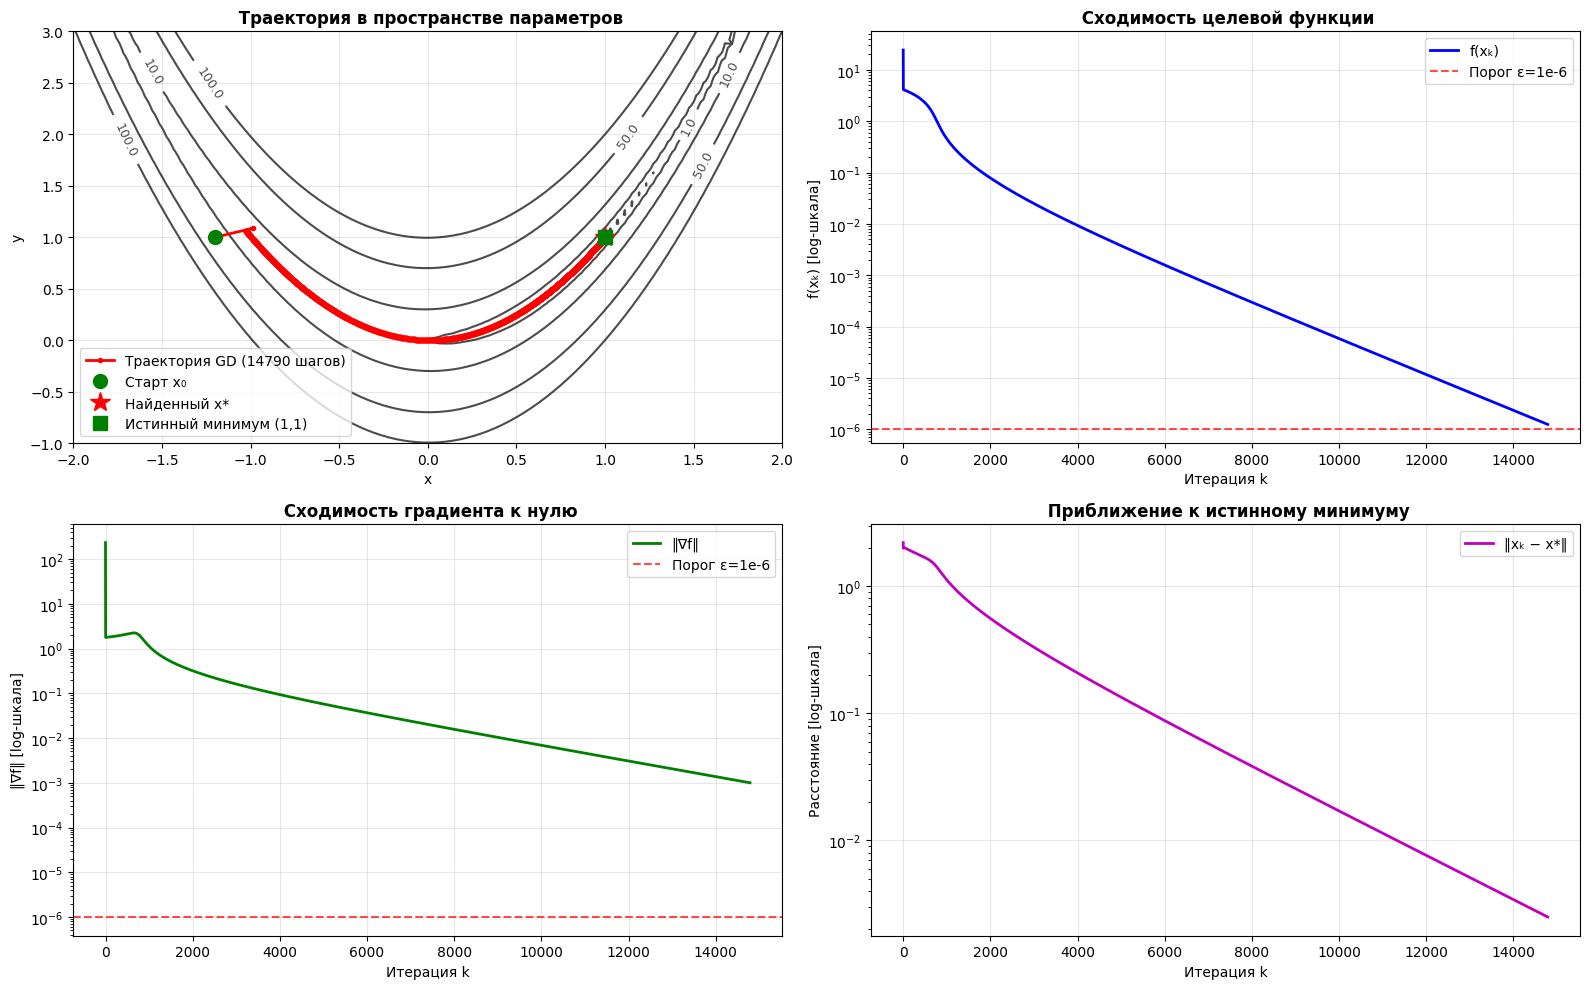


🎯 ИТОГОВЫЙ ОТЧЁТ: ГРАДИЕНТНЫЙ СПУСК
Начальная точка:     x₀ = [-1.2000, 1.0000]
Найденная точка:     x* = [0.998883, 0.997763]
Истинный минимум:    (1.000000, 1.000000)
Значение функции:    f(x*) = 1.25e-06
Норма градиента:     ‖∇f(x*)‖ = 1.00e-03
Выполнено итераций:  14790
Ошибка по координатам: ‖x* − [1,1]‖ = 2.50e-03


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# === БЛОК 1: Безопасная векторизованная функция для построения контуров ===

def rosenbrock_vectorized(x, y):
    """
    Векторная версия функции Розенброка для работы с meshgrid.
    Принимает матрицы X, Y и возвращает матрицу значений Z.
    """
    return 100 * (y - x**2)**2 + (1 - x)**2


# === БЛОК 2: Функция визуализации траектории оптимизации ===

def plot_rosenbrock_trajectory(x_opt, history, x0):
    """
    Строит 4 графика для анализа работы градиентного спуска.

    Параметры:
    ----------
    x_opt : np.array
        Найденная точка минимума
    history : list
        История итераций: [(iter, x, grad_norm, f_value), ...]
    x0 : np.array
        Начальная точка
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))

    # -----------------------------------------------------------
    # ГРАФИК 1: Траектория на контурном графике функции
    # -----------------------------------------------------------
    # Создаём сетку для построения контуров
    x_range = np.linspace(-2, 2, 100)
    y_range = np.linspace(-1, 3, 100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = rosenbrock_vectorized(X, Y)  # Вычисляем значения функции на сетке

    # Извлекаем координаты траектории из истории
    path_x = np.array([h[1][0] for h in history])  # Координата x на каждой итерации
    path_y = np.array([h[1][1] for h in history])  # Координата y на каждой итерации

    # Рисуем контурные линии уровня функции
    levels = [0.1, 1, 10, 50, 100]  # Уровни для отображения
    contour = ax1.contour(X, Y, Z, levels=levels, colors='black', alpha=0.7)
    ax1.clabel(contour, inline=True, fontsize=9)  # Подписываем уровни

    # Рисуем траекторию градиентного спуска
    ax1.plot(path_x, path_y, 'r.-', linewidth=2, markersize=6,
             label=f'Траектория GD ({len(history)} шагов)')

    # Отмечаем ключевые точки
    ax1.plot(x0[0], x0[1], 'go', markersize=10, label=f'Старт x₀')
    ax1.plot(x_opt[0], x_opt[1], 'r*', markersize=15, label=f'Найденный x*')
    ax1.plot(1, 1, 'gs', markersize=10, label='Истинный минимум (1,1)')

    ax1.set_xlabel('x'); ax1.set_ylabel('y')
    ax1.set_title(' Траектория в пространстве параметров', fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    # -----------------------------------------------------------
    # ГРАФИК 2: Сходимость значения функции f(xₖ)
    # -----------------------------------------------------------
    f_values = np.array([h[3] for h in history])  # Значения функции на итерациях
    iterations = np.arange(len(history))

    # Логарифмическая шкала по Y: видно убывание на много порядков
    ax2.semilogy(iterations, f_values, 'b-', linewidth=2, label='f(xₖ)')
    ax2.axhline(y=1e-6, color='r', ls='--', alpha=0.7, label='Порог ε=1e-6')
    ax2.set_xlabel('Итерация k'); ax2.set_ylabel('f(xₖ) [log-шкала]')
    ax2.set_title(' Сходимость целевой функции', fontweight='bold')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    # -----------------------------------------------------------
    # ГРАФИК 3: Сходимость нормы градиента ‖∇f‖
    # -----------------------------------------------------------
    grad_norms = np.array([h[2] for h in history])  # Нормы градиента

    ax3.semilogy(iterations, grad_norms, 'g-', linewidth=2, label='‖∇f‖')
    ax3.axhline(y=1e-6, color='r', ls='--', alpha=0.7, label='Порог ε=1e-6')
    ax3.set_xlabel('Итерация k'); ax3.set_ylabel('‖∇f‖ [log-шкала]')
    ax3.set_title(' Сходимость градиента к нулю', fontweight='bold')
    ax3.legend(); ax3.grid(True, alpha=0.3)

    # -----------------------------------------------------------
    # ГРАФИК 4: Расстояние до истинного оптимума ‖xₖ − x*‖
    # -----------------------------------------------------------
    true_opt = np.array([1.0, 1.0])  # Известный глобальный минимум
    # Вычисляем евклидово расстояние от каждой точки траектории до (1,1)
    distances = np.array([np.linalg.norm(h[1] - true_opt) for h in history])

    ax4.semilogy(iterations, distances, 'm-', linewidth=2, label='‖xₖ − x*‖')
    ax4.set_xlabel('Итерация k'); ax4.set_ylabel('Расстояние [log-шкала]')
    ax4.set_title(' Приближение к истинному минимуму', fontweight='bold')
    ax4.legend(); ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------------
    # БЛОК 3: Итоговая статистика в консоль
    # -----------------------------------------------------------
    print("\n" + "="*60)
    print("🎯 ИТОГОВЫЙ ОТЧЁТ: ГРАДИЕНТНЫЙ СПУСК")
    print("="*60)
    print(f"Начальная точка:     x₀ = [{x0[0]:.4f}, {x0[1]:.4f}]")
    print(f"Найденная точка:     x* = [{x_opt[0]:.6f}, {x_opt[1]:.6f}]")
    print(f"Истинный минимум:    (1.000000, 1.000000)")
    print(f"Значение функции:    f(x*) = {rosenbrock(x_opt):.2e}")
    print(f"Норма градиента:     ‖∇f(x*)‖ = {np.linalg.norm(rosen_grad(x_opt)):.2e}")
    print(f"Выполнено итераций:  {len(history)}")
    print(f"Ошибка по координатам: ‖x* − [1,1]‖ = {np.linalg.norm(x_opt - [1,1]):.2e}")
    print("="*60)


# === БЛОК 4: Запуск визуализации ===

plot_rosenbrock_trajectory(x_opt, history, x0)

### 🔍 Интерпретация графиков: что мы видим?

1.  **🌀 Траектория на контурах**:
    *   «Зигзагообразное» движение — характерный признак градиентного спуска в овраге
    *   Алгоритм «прижимается» к дну долины, но медленно продвигается вдоль неё
    *   Видно, почему требуется так много итераций: каждый шаг маленький из-за адаптивного уменьшения шага

2.  **📉 Сходимость f(xₖ)**:
    *   Быстрое убывание вначале (когда градиент большой)
    *   Затем «плато» — функция меняется очень медленно, хотя до оптимума ещё далеко
    *   Лог-шкала показывает: чтобы уменьшить ошибку в 10 раз, нужно ~100-200 дополнительных итераций

3.  **📊 Сходимость градиента**:
    *   Норма градиента убывает, но не монотонно (из-за адаптивного шага)
    *   Когда ‖∇f‖ достигает порога ε — алгоритм останавливается
    *   Важно: малый градиент ≠ близость к глобальному минимуму (может быть локальный!)

## Батчевый градиентный спуск для решения линейных систем Ax = b

**Цель:** Понять, как размер батча влияет на скорость сходимости, стабильность и точность решения задачи наименьших квадратов.

**Постановка задачи:**
Дана переопределённая система $Ax \approx b$ с шумом в правой части. Требуется найти вектор $x$, минимизирующий функционал:
$$L(x) = \frac{1}{2} \|Ax - b\|^2$$



🎯 ГРАДИЕНТНЫЙ СПУСК В PYTORCH (ДЕМО)
📋 Конфигурация:
   • Батч: 64 | Шаги: 1000 | lr: 0.02
   • Данные: 100 уравнений, шум σ=0.5

📊 Генерация данных...
   Истинное решение: x_true = [1.00, -1.00]

🚀 Запуск градиентного спуска...
   Шаг    0: L = 0.323707
   Шаг  100: L = 0.121179
   Шаг  200: L = 0.099044
   Шаг  300: L = 0.110021
   Шаг  400: L = 0.152366
   Шаг  500: L = 0.101202
   Шаг  600: L = 0.108499
   Шаг  700: L = 0.116247
   Шаг  800: L = 0.117438
   Шаг  900: L = 0.092159
   Найдено: x_found = [1.0171, -0.9764]

✅ Ошибка: ||x_found - x_true|| = 0.0291
✅ Финальные потери: L = 0.106328



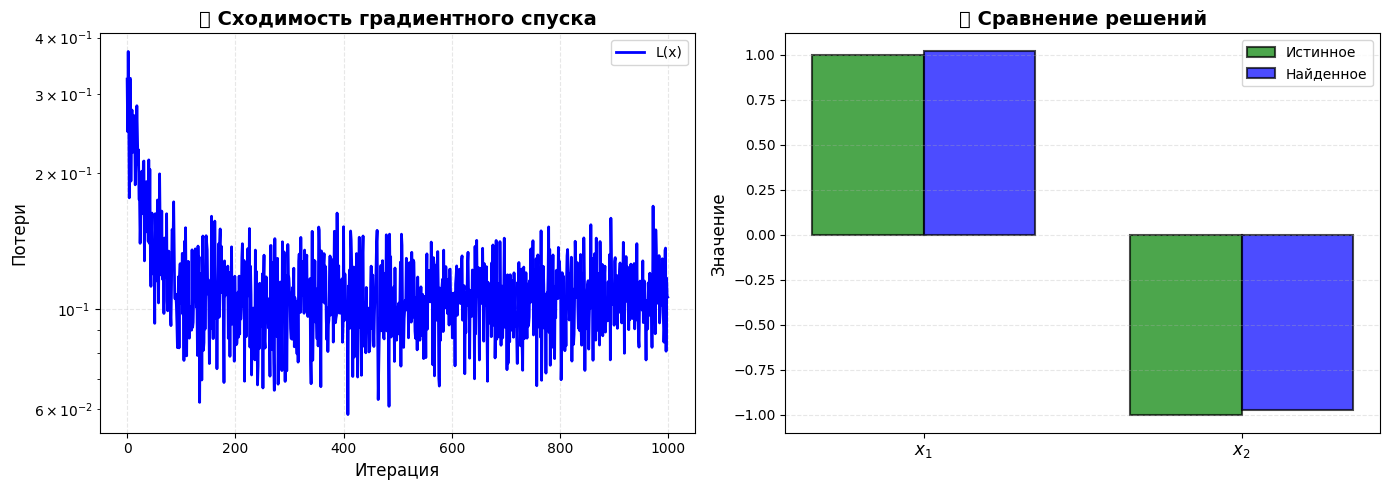

In [ ]:
# ==============================================================================
# 📦 НАСТРОЙКИ И ИМПОРТЫ
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import warnings
from dataclasses import dataclass

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)


# ==============================================================================
# 🎛️ КОНФИГУРАЦИЯ ЧЕРЕЗ DATACLASS
# ==============================================================================
@dataclass
class Config:
    """
    Единый блок настроек эксперимента.
    Меняйте значения здесь — они применятся везде.
    """
    # Параметры данных
    n_samples: int = 100           # Количество уравнений в системе
    n_features: int = 2            # Количество неизвестных
    noise_std: float = 0.5         # Уровень шума в правой части b
    seed_data: int = 42            # Seed для генерации данных

    # Параметры оптимизации
    batch_size: int = 32           # Размер мини-батча
    steps: int = 500               # Число итераций оптимизации
    lr: float = 0.05               # Размер шага (learning rate)
    seed_optim: int = 42           # Seed для воспроизводимости оптимизации

    # Параметры вывода
    verbose: bool = True           # Показывать прогресс
    plot: bool = True              # Строить графики


# Создаём глобальный объект конфигурации
CFG = Config()


# ==============================================================================
# 1️⃣ ГЕНЕРАЦИЯ ДАННЫХ: Система Ax = b с шумом
# ==============================================================================
def generate_data(cfg: Config):
    """
    Создаёт линейную систему с известным истинным решением.
    """
    torch.manual_seed(cfg.seed_data)
    np.random.seed(cfg.seed_data)

    # Матрица A (случайная)
    A = torch.randn(cfg.n_samples, cfg.n_features)

    # Истинное решение (фиксированное для воспроизводимости)
    x_true = torch.tensor([1.0, -1.0])

    # Правая часть b = Ax + шум
    b = A @ x_true + cfg.noise_std * torch.randn(cfg.n_samples)

    return A, b, x_true


# ==============================================================================
# 2️⃣ ГРАДИЕНТНЫЙ СПУСК: Основной алгоритм
# ==============================================================================
def gradient_descent(A: torch.Tensor, b: torch.Tensor, cfg: Config):
    """
    Минимизирует L(x) = ½||Ax - b||² методом стохастического градиентного спуска.
    """
    # 🔹 Инициализация оптимизируемого параметра
    x = nn.Parameter(torch.tensor([1.5, -1.5]))

    # 🔹 Оптимизатор SGD
    optimizer = optim.SGD([x], lr=cfg.lr)

    # 🔹 Контейнеры для истории
    losses = []
    trajectory = []

    n_samples = A.shape[0]
    torch.manual_seed(cfg.seed_optim)

    for step in range(cfg.steps):
        optimizer.zero_grad()  # Обнуление градиентов

        # 🎲 Случайный мини-батч
        indices = torch.randint(0, n_samples, (cfg.batch_size,))
        A_batch, b_batch = A[indices], b[indices]

        # 🔹 Функция потерь на батче
        residual = A_batch @ x - b_batch
        loss = 0.5 * (residual ** 2).mean()

        # 🔹 Автоматическое дифференцирование
        loss.backward()

        # 🔹 Шаг оптимизации
        optimizer.step()

        # Логгирование
        losses.append(loss.item())
        trajectory.append(x.clone().detach().numpy())

        # Прогресс в консоль
        if cfg.verbose and step % 100 == 0:
            print(f"   Шаг {step:4d}: L = {loss.item():.6f}")

    return np.array(losses), np.array(trajectory), x.detach().numpy()


# ==============================================================================
# 3️⃣ ВИЗУАЛИЗАЦИЯ
# ==============================================================================
def plot_results(losses: np.array, trajectory: np.array,
                 x_true: np.array, x_found: np.array):
    """Строит графики сходимости и сравнения решений."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # График 1: Сходимость функции потерь
    ax1.plot(losses, 'b-', linewidth=2, label='L(x)')
    ax1.set_xlabel('Итерация', fontsize=12)
    ax1.set_ylabel('Потери', fontsize=12)
    ax1.set_title('📉 Сходимость градиентного спуска', fontweight='bold', fontsize=14)
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(fontsize=10)

    # График 2: Сравнение решений
    labels = ['$x_1$', '$x_2$']
    x_pos = np.arange(len(labels))
    width = 0.35

    # ✅ ИСПРАВЛЕНО: edgecolor (без 's' на конце)
    ax2.bar(x_pos - width/2, x_true, width, label='Истинное',
            color='green', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax2.bar(x_pos + width/2, x_found, width, label='Найденное',
            color='blue', alpha=0.7, edgecolor='black', linewidth=1.5)

    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(labels, fontsize=12)
    ax2.set_ylabel('Значение', fontsize=12)
    ax2.set_title('🎯 Сравнение решений', fontweight='bold', fontsize=14)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.legend(fontsize=10)

    plt.tight_layout()
    plt.show()


# ==============================================================================
# 4️⃣ ГЛАВНАЯ ФУНКЦИЯ
# ==============================================================================
def main(cfg: Config):
    """Запуск эксперимента с заданной конфигурацией."""
    print("\n" + "="*60)
    print("🎯 ГРАДИЕНТНЫЙ СПУСК В PYTORCH (ДЕМО)")
    print("="*60)
    print(f"📋 Конфигурация:")
    print(f"   • Батч: {cfg.batch_size} | Шаги: {cfg.steps} | lr: {cfg.lr}")
    print(f"   • Данные: {cfg.n_samples} уравнений, шум σ={cfg.noise_std}")
    print("="*60 + "\n")

    # 1. Генерация данных
    print("📊 Генерация данных...")
    A, b, x_true = generate_data(cfg)
    print(f"   Истинное решение: x_true = [{x_true[0]:.2f}, {x_true[1]:.2f}]")

    # 2. Оптимизация
    print("\n🚀 Запуск градиентного спуска...")
    losses, trajectory, x_found = gradient_descent(A, b, cfg)
    print(f"   Найдено: x_found = [{x_found[0]:.4f}, {x_found[1]:.4f}]")

    # 3. Оценка точности
    error = np.linalg.norm(x_found - x_true.numpy())
    print(f"\n✅ Ошибка: ||x_found - x_true|| = {error:.4f}")
    print(f"✅ Финальные потери: L = {losses[-1]:.6f}")
    print("="*60 + "\n")

    # 4. Визуализация
    if cfg.plot:
        plot_results(losses, trajectory, x_true.numpy(), x_found)


# ==============================================================================
# ▶️ ЗАПУСК
# ==============================================================================
if __name__ == "__main__":

    # 🔧 БЫСТРАЯ НАСТРОЙКА — меняйте параметры здесь:

    # Вариант 1: Быстрый запуск (демо)
    # CFG.steps = 200
    # CFG.lr = 0.1

    # Вариант 2: Высокая точность
    CFG.steps = 1000
    CFG.lr = 0.02
    CFG.batch_size = 64

    # Вариант 3: Отладка
    # CFG.verbose = True
    # CFG.seed_optim = 123

    main(CFG)

## Условная оптимизация

##  Условная оптимизация (с ограничениями)

В реальных задачах параметры часто имеют ограничения (budget, физические пределы, балансовые соотношения).
Рассмотрим задачу поиска минимума функции при наличии ограничения-равенства.

**Задача:**
$$ \min_{x} f(x) = (x_1 - 1)^2 + (x_2 - 2)^2 $$
**При условии:**
$$ x_1 + x_2 = 1 $$

*Геометрический смысл:* Мы ищем точку на прямой $x_1 + x_2 = 1$, которая ближе всего к точке $(1, 2)$.
*Ожидаемое решение:* Аналитически через множители Лагранжа можно найти, что optimum должен быть в точке **$x^* = [0, 1]$**.

**Метод:** `SLSQP` (Sequential Least Squares Programming).
В отличие от BFGS, этот метод поддерживает ограничения (равенства и неравенства).

In [ ]:
import numpy as np
from scipy.optimize import minimize

# 1. Целевая функция
def f(x):
    """
    Квадратичная функция. Глобальный минимум без ограничений в точке [1, 2].
    """
    return (x[0] - 1)**2 + (x[1] - 2)**2

# 2. Формализация ограничений
# SciPy ожидает ограничения в виде словаря (или списка словарей).
# Для равенства: fun(x) = 0. Поэтому пишем x[0] + x[1] - 1 = 0.
cons = {
    "type": "eq",               # тип ограничения: 'eq' (равенство) или 'ineq' (неравенство)
    "fun": lambda x: x[0] + x[1] - 1  # функция ограничения g(x)
}

# 3. Начальное приближение
x0 = np.array([0.0, 0.0])

# 4. Запуск оптимизации
# method='SLSQP' обязателен, так как есть ограничения.
# BFGS или Nelder-Mead здесь не подойдут (игнорируют constraints).
res = minimize(f, x0, method="SLSQP", constraints=cons)

# 5. Вывод результатов
print("=== Протокол условной оптимизации ===")
print(f"Статус успеха: {res.success}")
print(f"Сообщение: {res.message}")
print(f"Найденная точка минимума x*: {res.x}")
print(f"Значение функции f(x*): {res.fun:.6f}")

# 6. Проверка выполнения ограничений (Важный этап!)
# В численных методах ограничения выполняются с некоторой точностью (tolerance)
constraint_value = res.x[0] + res.x[1] - 1
print(f"\n=== Проверка ограничений ===")
print(f"Левая часть условия (x1 + x2 - 1): {constraint_value:.2e}")


=== Протокол условной оптимизации ===
Статус успеха: True
Сообщение: Optimization terminated successfully
Найденная точка минимума x*: [2.98023251e-09 9.99999997e-01]
Значение функции f(x*): 2.000000

=== Проверка ограничений ===
Левая часть условия (x1 + x2 - 1): 0.00e+00


### 📝 Выводы по результату

1.  **Влияние ограничений:** Обратите внимание, что найденная точка $x^* \approx [0, 1]$ отличается от безусловного минимума $[1, 2]$. Алгоритм "проецирует" решение на допустимую область (прямую линию).

2.  **Валидация:** В условной оптимизации недостаточно проверить только успех (`success`). **Критически важно** проверять величину нарушения ограничений (constraint violation), как показано в блоке проверки. В реальных задачах допустимое отклонение задается техническим заданием.



## Оптимизация с граничными условиями (Box Constraints)

Частный, но очень важный случай ограничений — когда каждая переменная имеет нижнюю и верхнюю границу.
В отличие от общих ограничений (`constraints`), границы обрабатываются алгоритмом более эффективно.

**Задача:**
$$ \min_{x} f(x) = (x_1 - 1)^2 + (x_2 - 3)^2 + \sin^2(3x_1) $$
**Ограничения:**
$$ 0 \le x_1 \le 2, \quad 1 \le x_2 \le 4 $$

**Особенность функции:** Слагаемое $\sin^2(3x_1)$ делает функцию **невыпуклой** (многоэкстремальной).
Существует риск попадания в локальный минимум, а не глобальный.

**Метод:** `L-BFGS-B`.
Буква **"B"** в названии означает **Bounds**. Это модификация квазиньютоновского метода, специально оптимизированная для работы с границами переменных.

In [ ]:
import numpy as np
from scipy.optimize import minimize

# 1. Целевая функция
def f(x):
    """
    Сумма квадратичной функции и осциллирующей компоненты.
    sin^2 создает локальные минимумы, усложняя поиск глобального экстремума.
    """
    return (x[0] - 1)**2 + (x[1] - 3)**2 + np.sin(3*x[0])**2

# 2. Границы переменных (Bounds)
# Формат: список кортежей (min, max) для каждой переменной.
# None означает отсутствие границы (например, (0, None) -> x >= 0)
bounds = [
    (0, 2),   # 0 <= x0 <= 2
    (1, 4)    # 1 <= x1 <= 4
]

# 3. Начальное приближение
# Должно находиться внутри допустимой области (желательно)
x0 = np.array([0.5, 1.0])

# 4. Запуск оптимизации
# L-BFGS-B эффективнее SLSQP для простых границ, так как использует специфичную структуру задачи
res = minimize(f, x0, method="L-BFGS-B", bounds=bounds)

# 5. Вывод результатов
print("=== Протокол оптимизации с границами ===")
print(f"Статус успеха: {res.success}")
print(f"Найденная точка минимума x*: {res.x}")
print(f"Значение функции f(x*): {res.fun:.6f}")

# 6. Анализ положения решения (Важно для инженерии!)
# Проверяем, не оказалось ли решение на самой границе допустимой области
print(f"\n=== Анализ границ ===")
for i, (b_low, b_high) in enumerate(bounds):
    val = res.x[i]
    if np.isclose(val, b_low):
        print(f"x[{i}] уперся в НИЖНЮЮ границу ({b_low})")
    elif np.isclose(val, b_high):
        print(f"x[{i}] уперся в ВЕРХНЮЮ границу ({b_high})")
    else:
        print(f"x[{i}] находится внутри диапазона ({b_low} < {val:.3f} < {b_high})")

=== Протокол оптимизации с границами ===
Статус успеха: True
Найденная точка минимума x*: [1.04247717 3.00000011]
Значение функции f(x*): 0.002005

=== Анализ границ ===
x[0] находится внутри диапазона (0 < 1.042 < 2)
x[1] находится внутри диапазона (1 < 3.000 < 4)


### 📝 Выводы по результату

1.  **Эффективность метода:** Для задач только с границами переменных `L-BFGS-B` обычно работает быстрее и устойчивее, чем универсальный `SLSQP`.
2.  **Решение на границе:** В инженерных задачах оптимальное решение часто лежит **на границе** допустимой области (например, максимальная нагрузка, минимальная стоимость). Блок проверки в коде помогает это выявить.
3.  **Локальные минимумы:** Из-за наличия $\sin^2(3x_1)$ функция имеет несколько "ям". Если бы мы выбрали другое начальное приближение `x0`, алгоритм мог бы сойтись в другой локальный минимум.
    *   *Совет:* Для невыпуклых задач рекомендуется запускать оптимизацию с нескольких разных начальных точек (Multistart).
4.  **Формат границ:** Обратите внимание на гибкость задания границ — можно использовать `None`, если переменная не ограничена сверху или снизу.

###  Сравнение методов условной оптимизации: штраф, барьер и SLSQP

Рассмотрим одну задачу тремя разными подходами, чтобы понять их философию и область применения.

**Задача:**
$$ \min_{x,y} f(x,y) = (x-2)^2 + (y-1)^2 $$
**При ограничении:**
$$ x + y \le 2 $$

*Аналитическое решение:* Проекция точки $(2, 1)$ на прямую $x+y=2$ даёт оптимум **$(1.5, 0.5)$**.

**Три метода:**
1.  **Внешний штраф** — начинаем *снаружи* допустимой области, "штрафуем" за нарушение.
2.  **Логарифмический барьер** — начинаем *внутри* области, строим "стену" на границе.
3.  **SLSQP** — прямой метод, который работает с ограничениями нативно (без преобразования функции).

🚀 Запуск методов условной оптимизации...
   🟦 Штраф ρ=   1 → x=[1.66666666 0.66666666]
   🟦 Штраф ρ=   5 → x=[1.54545454 0.54545454]
   🟦 Штраф ρ=  20 → x=[1.51219512 0.51219512]
   🟦 Штраф ρ= 100 → x=[1.50248756 0.50248756]
   🟦 Штраф ρ= 500 → x=[1.5004995 0.5004995]
   🟩 Барьер t= 0.5 → x=[9.99999846e-01 1.53292370e-07]
   🟩 Барьер t= 1.0 → x=[1.19098299 0.19098309]
   🟩 Барьер t= 2.0 → x=[1.31698729 0.31698729]
   🟩 Барьер t= 5.0 → x=[1.4145898 0.4145898]
   🟩 Барьер t=10.0 → x=[1.45419601 0.45419602]
   🟩 Барьер t=20.0 → x=[1.47613872 0.47613872]
   🟨 SLSQP → x=[1.5 0.5], f(x)=0.500000, успех=True
✅ Готово!



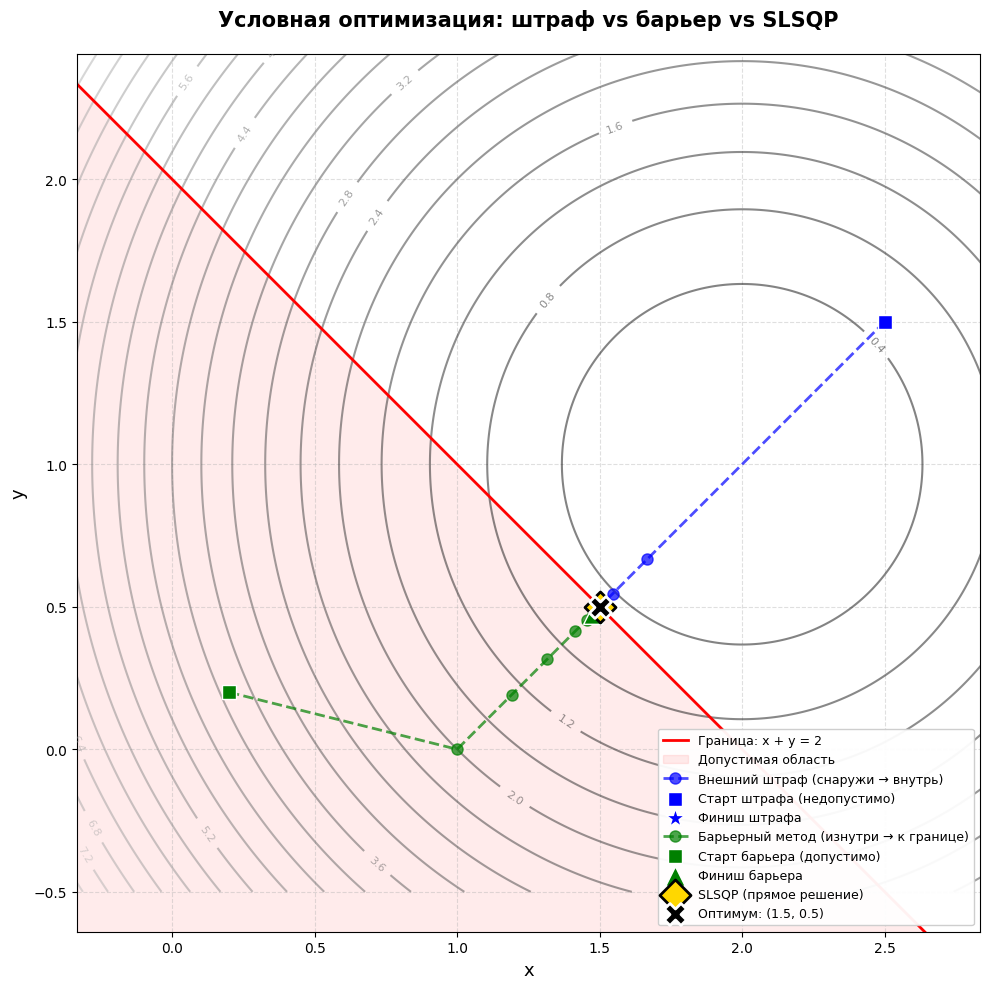

In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 10)


# ==============================================================================
# 1️⃣ ПОСТАНОВКА ЗАДАЧИ: Целевая функция и ограничение
# ==============================================================================
def f(xy):
    """
    Целевая функция: f(x,y) = (x-2)² + (y-1)²
    Минимум без ограничений: (2, 1)
    """
    x, y = xy
    return (x - 2)**2 + (y - 1)**2

def g(xy):
    """
    Ограничение-неравенство: g(x,y) = x + y - 2 ≤ 0
    Возвращает значение: отрицательное → допустимо, положительное → нарушение
    """
    x, y = xy
    return x + y - 2


# ==============================================================================
# 2️⃣ МЕТОД ВНЕШНЕГО ШТРАФА (Exterior Penalty)
# ==============================================================================
def penalty_external(xy, rho):
    """
    Функция с квадратичным внешним штрафом.
    F(x) = f(x) + ρ · [max(0, g(x))]²
    """
    violation = max(0.0, g(xy))
    return f(xy) + rho * violation**2


# ==============================================================================
# 3️⃣ ЛОГАРИФМИЧЕСКИЙ БАРЬЕРНЫЙ МЕТОД (Interior Point)
# ==============================================================================
def barrier_log(xy):
    """
    Логарифмический барьер: -ln(-g(x))
    Определён только при g(x) < 0 (строго внутри области)
    """
    val = g(xy)
    if val >= 0:
        return np.inf
    return -np.log(-val)

def barrier_objective(xy, t):
    """
    Барьерная функция с параметром t: F(x) = t · f(x) - ln(-g(x))
    """
    b = barrier_log(xy)
    if not np.isfinite(b):
        return np.inf
    return t * f(xy) + b


# ==============================================================================
# 4️⃣ ЗАПУСК МЕТОДОВ: Построение траекторий сходимости
# ==============================================================================
def run_external_penalty_path():
    """Траектория метода внешнего штрафа. Старт СНАРУЖИ допустимой области."""
    x0 = np.array([2.5, 1.5])  # Недопустимая точка: 2.5+1.5=4 > 2
    rhos = [1, 5, 20, 100, 500]
    xs = [x0]

    x_current = x0.copy()
    for rho in rhos:
        res = minimize(lambda z: penalty_external(z, rho), x_current, method="BFGS")
        x_current = res.x
        xs.append(x_current)
        print(f"   🟦 Штраф ρ={rho:4d} → x={x_current}")

    return np.array(xs)

def run_barrier_path():
    """Траектория барьерного метода. Старт СТРОГО ВНУТРИ допустимой области."""
    x0 = np.array([0.2, 0.2])  # Допустимая точка: 0.2+0.2=0.4 < 2
    ts = [0.5, 1, 2, 5, 10, 20]
    xs = [x0]

    x_current = x0.copy()
    for t in ts:
        res = minimize(lambda z: barrier_objective(z, t), x_current, method="BFGS")
        x_current = res.x
        xs.append(x_current)
        print(f"   🟩 Барьер t={t:4.1f} → x={x_current}")

    return np.array(xs)

# Решение методом SLSQP (прямая работа с ограничениями)
def run_slqp_solution():
    """
    Прямое решение через SLSQP.
    Не требует преобразования функции — ограничения передаются явно.
    """
    x0 = np.array([1.0, 1.0])  # Начальное приближение (можно любое)

    # Ограничение в формате SciPy: g(x) <= 0 задаётся как 'ineq': -g(x) >= 0
    # То есть: 2 - x - y >= 0  <=>  x + y <= 2
    cons = {"type": "ineq", "fun": lambda xy: 2 - xy[0] - xy[1]}

    res = minimize(f, x0, method="SLSQP", constraints=cons)
    print(f"   🟨 SLSQP → x={res.x}, f(x)={res.fun:.6f}, успех={res.success}")
    return res.x

print("🚀 Запуск методов условной оптимизации...")
penalty_path = run_external_penalty_path()
barrier_path = run_barrier_path()
slqp_solution = run_slqp_solution()  # 🔹 Запуск SLSQP
print("✅ Готово!\n")


# ==============================================================================
# 5️⃣ ВИЗУАЛИЗАЦИЯ: Сравнение траекторий
# ==============================================================================
opt_x = np.array([1.5, 0.5])  # Истинный оптимум

plt.figure(figsize=(10, 10))

# --- Фон: контуры целевой функции ---
x_lin = np.linspace(-0.5, 3, 400)
y_lin = np.linspace(-0.5, 3, 400)
X, Y = np.meshgrid(x_lin, y_lin)
Z = (X - 2)**2 + (Y - 1)**2

cs = plt.contour(X, Y, Z, levels=25, cmap="gray", alpha=0.5)
plt.clabel(cs, inline=True, fontsize=8, fmt='%.1f')

# --- Ограничение: линия x + y = 2 ---
xx = np.linspace(-0.5, 3, 200)
yy = 2 - xx
plt.plot(xx, yy, 'r-', linewidth=2, label="Граница: x + y = 2")
plt.fill_between(xx, yy, -2, color='red', alpha=0.08, label="Допустимая область")

# --- Траектория внешнего штрафа (синяя) ---
plt.plot(penalty_path[:, 0], penalty_path[:, 1],
         'bo--', linewidth=2, markersize=8, alpha=0.7,
         label="Внешний штраф (снаружи → внутрь)")
plt.scatter(penalty_path[0, 0], penalty_path[0, 1],
            c='blue', s=100, marker='s', edgecolors='white',
            label="Старт штрафа (недопустимо)", zorder=5)
plt.scatter(penalty_path[-1, 0], penalty_path[-1, 1],
            c='blue', s=200, marker='*', edgecolors='white',
            label="Финиш штрафа", zorder=5)

# --- Траектория барьерного метода (зелёная) ---
plt.plot(barrier_path[:, 0], barrier_path[:, 1],
         'go--', linewidth=2, markersize=8, alpha=0.7,
         label="Барьерный метод (изнутри → к границе)")
plt.scatter(barrier_path[0, 0], barrier_path[0, 1],
            c='green', s=100, marker='s', edgecolors='white',
            label="Старт барьера (допустимо)", zorder=5)
plt.scatter(barrier_path[-1, 0], barrier_path[-1, 1],
            c='green', s=200, marker='^', edgecolors='white',
            label="Финиш барьера", zorder=5)

# 🔹 Точка решения SLSQP (жёлтая)
plt.scatter(slqp_solution[0], slqp_solution[1],
            c='gold', s=250, marker='D', edgecolors='black', linewidth=2,
            label="SLSQP (прямое решение)", zorder=10)

# --- Истинный оптимум ---
plt.scatter(opt_x[0], opt_x[1],
            c='black', s=250, marker='X', edgecolors='white', linewidth=2,
            label=f"Оптимум: ({opt_x[0]}, {opt_x[1]})", zorder=10)

# --- Оформление ---
plt.xlabel("x", fontsize=13)
plt.ylabel("y", fontsize=13)
plt.title("Условная оптимизация: штраф vs барьер vs SLSQP", fontsize=15, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=9, framealpha=0.95)
plt.axis("equal")
plt.xlim(-0.3, 2.8)
plt.ylim(-0.5, 2.3)
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

### 📝 Ключевые различия трёх подходов

| Метод | Подход к ограничениям | Старт | Преимущества | Недостатки |
|-------|----------------------|-------|--------------|------------|
| **Внешний штраф** | Преобразует задачу: добавляет штраф за нарушение | Снаружи допустимой области | Прост в реализации; не требует допустимого старта | При больших ρ задача становится плохо обусловленной; сходится *к* границе, но не на неё |
| **Логарифмический барьер** | Преобразует задачу: добавляет "стену" на границе | Строго внутри допустимой области | Траектория всегда допустима; хорошая численная устойчивость | Требует допустимого старта; не работает с ограничениями-равенствами |
| **SLSQP** | Работает с ограничениями нативно (через множители Лагранжа) | Любой (допустимый или нет) | Не нужно преобразовывать функцию; поддерживает равенства и неравенства; точное соблюдение границ | Требует вычисления градиентов; может застрять в локальном минимуме |

### 🔍 Что видим на графике?
1.  **Синяя траектория (штраф):** Начинается вне допустимой области и постепенно "притягивается" к границе снизу.
2.  **Зелёная траектория (барьер):** Начинается внутри и движется к границе, но никогда её не пересекает.
3.  **Жёлтая точка (SLSQP):** Прямое решение



## Регуляризация Тихонова в задаче линейной регрессии

**Проблема:** При наличии шума в данных или при плохой обусловленности задачи, метод наименьших квадратов (МНК) может давать «раздутые» коэффициенты, которые плохо обобщаются.

**Решение:** Добавить штраф за большие значения параметров — **регуляризацию Тихонова (L2)**.

**Задача:**
$$ \min_{a,b} J(a,b) = \underbrace{\sum_{i=1}^n (a x_i + b - y_i)^2}_{\text{Точность на данных}} + \underbrace{\alpha \cdot (a^2 + b^2)}_{\text{Штраф за сложность}} $$

**Параметр α (alpha):**
- α = 0 → обычный МНК (минимум ошибки на обучающих данных)
- α → ∞ → параметры стремятся к нулю (простая, но, возможно, неточная модель)
- Выбор α — это баланс между **смещением** (bias) и **разбросом** (variance).

**Цель примера:** Увидеть, как регуляризация «усмиряет» коэффициенты модели, жертвуя небольшой точностью на обучающих данных ради устойчивости.

📊 РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ

🔴 Без регуляризации (обычный МНК):
   Статус: ✓ Успех
   Найденные параметры: a = 2.0771, b = -1.1792
   Ошибка на данных (MSE): 0.3600
   Истинные параметры:     a = 2.0, b = -1.0

🔵 С регуляризацией Тихонова (α = 1.0):
   Статус: ✓ Успех
   Найденные параметры: a = 2.0103, b = -0.9797
   Полная функция J(a,b): 16.1320
   ├─ Ошибка на данных:   0.3710
   └─ Штраф α·(a²+b²):    5.0012

🎯 Отклонение от истинных [a, b]:
   Без регуляризации: 0.1951
   С регуляризацией:  0.0228


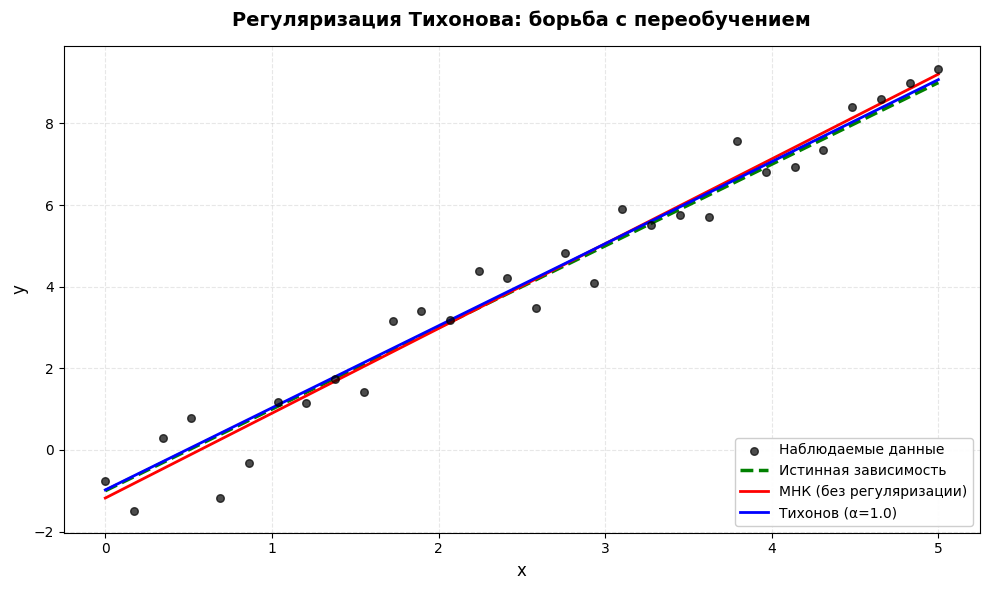

In [ ]:
# ==============================================================================
# 📦 ИМПОРТЫ И НАСТРОЙКИ
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ==============================================================================
# 1️⃣ ГЕНЕРАЦИЯ "ЭКСПЕРИМЕНТАЛЬНЫХ" ДАННЫХ
# ==============================================================================
rng = np.random.default_rng(seed=42)  # Фиксируем seed для воспроизводимости

x_data = np.linspace(0, 5, 30)         # 30 точек на отрезке [0, 5]
a_true, b_true = 2.0, -1.0             # Истинные параметры модели
noise = rng.normal(scale=0.8, size=x_data.size)  # Гауссов шум, σ = 0.8
y_data = a_true * x_data + b_true + noise        # Наблюдаемые данные: y = ax + b + ε

# ==============================================================================
# 2️⃣ МОДЕЛЬ И ЦЕЛЕВЫЕ ФУНКЦИИ
# ==============================================================================
def model(x, a, b):
    """Линейная модель: y = a*x + b"""
    return a * x + b

def objective(params, x, y):
    """
    Целевая функция без регуляризации: сумма квадратов невязок (МНК).
    Минимизируем только ошибку предсказания.
    """
    a, b = params
    y_pred = model(x, a, b)
    residuals = y_pred - y
    return np.sum(residuals**2)

def objective_tikhonov(params, x, y, alpha):
    """
    Целевая функция с регуляризацией Тихонова (L2-штраф).

    J(a,b) = ||X·w - y||² + α·||w||²

    • data_term: точность подгонки под данные
    • reg_term: штраф за большие коэффициенты (предотвращает переобучение)
    • alpha: гиперпараметр, управляющий балансом
    """
    a, b = params
    y_pred = model(x, a, b)

    data_term = np.sum((y_pred - y)**2)      # Ошибка на данных
    reg_term = alpha * (a**2 + b**2)          # Штраф Тихонова

    return data_term + reg_term

# ==============================================================================
# 3️⃣ ЗАПУСК ОПТИМИЗАЦИИ
# ==============================================================================
initial_guess = np.array([0.0, 0.0])  # Начальное приближение [a, b]
alpha = 1.0  # 👈 Параметр регуляризации: попробуйте изменить (0.01, 0.1, 1, 10)

# 🔹 Решение БЕЗ регуляризации (обычный МНК)
res_no_reg = minimize(objective, initial_guess, args=(x_data, y_data), method="BFGS")

# 🔹 Решение С регуляризацией Тихонова
res_reg = minimize(objective_tikhonov, initial_guess,
                   args=(x_data, y_data, alpha), method="BFGS")

# ==============================================================================
# 4️⃣ ВЫВОД И АНАЛИЗ РЕЗУЛЬТАТОВ
# ==============================================================================
print("📊 РЕЗУЛЬТАТЫ ОПТИМИЗАЦИИ")
print("=" * 60)

print("\n🔴 Без регуляризации (обычный МНК):")
print(f"   Статус: {'✓ Успех' if res_no_reg.success else '✗ Ошибка'}")
print(f"   Найденные параметры: a = {res_no_reg.x[0]:.4f}, b = {res_no_reg.x[1]:.4f}")
print(f"   Ошибка на данных (MSE): {objective(res_no_reg.x, x_data, y_data)/len(x_data):.4f}")
print(f"   Истинные параметры:     a = {a_true}, b = {b_true}")

print(f"\n🔵 С регуляризацией Тихонова (α = {alpha}):")
print(f"   Статус: {'✓ Успех' if res_reg.success else '✗ Ошибка'}")
print(f"   Найденные параметры: a = {res_reg.x[0]:.4f}, b = {res_reg.x[1]:.4f}")
print(f"   Полная функция J(a,b): {objective_tikhonov(res_reg.x, x_data, y_data, alpha):.4f}")
print(f"   ├─ Ошибка на данных:   {objective(res_reg.x, x_data, y_data)/len(x_data):.4f}")
print(f"   └─ Штраф α·(a²+b²):    {alpha * np.sum(res_reg.x**2):.4f}")

# 🔍 Сравнение отклонения от истинных параметров
error_no_reg = np.linalg.norm(res_no_reg.x - np.array([a_true, b_true]))
error_reg = np.linalg.norm(res_reg.x - np.array([a_true, b_true]))
print(f"\n🎯 Отклонение от истинных [a, b]:")
print(f"   Без регуляризации: {error_no_reg:.4f}")
print(f"   С регуляризацией:  {error_reg:.4f}")

# ==============================================================================
# 5️⃣ ВИЗУАЛИЗАЦИЯ
# ==============================================================================
a_est_no_reg, b_est_no_reg = res_no_reg.x
a_est_reg, b_est_reg = res_reg.x

# Создаём гладкую сетку для красивого графика
x_smooth = np.linspace(x_data.min(), x_data.max(), 200)
y_true_smooth = model(x_smooth, a_true, b_true)
y_fit_no_reg = model(x_smooth, a_est_no_reg, b_est_no_reg)
y_fit_reg = model(x_smooth, a_est_reg, b_est_reg)

plt.figure(figsize=(10, 6))

# Данные и истинная зависимость
plt.scatter(x_data, y_data, label="Наблюдаемые данные", color="black", s=30, alpha=0.7, zorder=5)
plt.plot(x_smooth, y_true_smooth, label="Истинная зависимость", color="green", linewidth=2.5, linestyle='--')

# Модели
plt.plot(x_smooth, y_fit_no_reg, label="МНК (без регуляризации)", color="red", linewidth=2)
plt.plot(x_smooth, y_fit_reg, label=f"Тихонов (α={alpha})", color="blue", linewidth=2)

# Оформление
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("Регуляризация Тихонова: борьба с переобучением", fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10, framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### 📝 Ключевые выводы по регуляризации

1.  **Что делает регуляризация?**
    *   Добавляет штраф за «большие» коэффициенты модели.
    *   Жертвует небольшой точностью на обучающих данных ради **устойчивости** решения.
    *   Предотвращает переобучение, особенно когда данных мало или они зашумлены.

2.  **Интерпретация результатов:**
    *   🔴 **Без регуляризации:** Модель стремится минимизировать ошибку на данных, что может привести к «раздутым» коэффициентам (особенно при мультиколлинеарности).
    *   🔵 **С регуляризацией:** Коэффициенты `a, b` сдвигаются ближе к нулю. Ошибка на данных немного растёт, но модель становится более устойчивой к шуму.

3.  **Выбор параметра α:**
    | α | Эффект | Когда использовать |
    |---|--------|-----------------|
    | 0 | Нет регуляризации | Данные чистые, задача хорошо обусловлена |
    | 0.01–0.1 | Слабый штраф | Легкая стабилизация, сохранение точности |
    | 1–10 | Умеренный штраф | Стандартный выбор при зашумленных данных |
    | >100 | Сильный штраф | Когда приоритет — простота модели, а не точность |

4.  **Практический совет:**
    *   Параметр α **не подбирается оптимизацией** — это гиперпараметр.
    *   Для выбора α используйте **кросс-валидацию**: разбейте данные на train/test и подберите α, которое даёт наименьшую ошибку на тестовой выборке.
    *   В `scikit-learn` это реализовано в `Ridge` (L2-регуляризация) и `Lasso` (L1-регуляризация).

### 💡 Физический смысл:
Регуляризация Тихонова эквивалентна **априорному предположению**, что «хорошие» параметры модели должны быть небольшими.